<div align="center">
    <h1><b>Hospital Appointment No-Show Prediction</b></h1>
    <p><b>Machine Learning Based Medical Project</b></p>
</div>


<h2>Project Description</h2>

<p>
This project aims to predict whether a patient will attend or miss a scheduled hospital appointment using Machine Learning techniques.
</p>

<p>
Patient no-shows result in wastage of doctors’ time, inefficient utilization of hospital resources, and increased waiting time for other patients.
</p>

<p>
By analyzing patient demographics, medical history, and appointment-related details, this project builds a predictive model that helps hospitals reduce no-show rates and improve overall healthcare efficiency.
</p>


<h2>Project Objectives</h2>
<p>
The main objective of this project is to analyze hospital appointment data and perform proper data cleaning and preprocessing to ensure quality and accuracy. The project also aims to explore the key factors that influence patient no-shows. Multiple machine learning models will be built and compared based on their performance in predicting appointment attendance. Finally, the best performing model will be selected to achieve accurate and reliable prediction of whether a patient will attend or miss a scheduled hospital appointment.
</p>


https://www.kaggle.com/datasets/joniarroba/noshowappointments

In [1]:
# Data handle cheyyan
import pandas as pd
import numpy as np

# Graph kaanan
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)
from sklearn.svm import SVC

# Train test split & scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Save model
import pickle

import warnings
warnings.filterwarnings("ignore")


In [2]:
df=pd.read_csv("KaggleV2-May-2016.csv")
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [4]:
df.shape

(110527, 14)

In [5]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [6]:
df.describe(include="O")#will give their category summary.

,Gender,ScheduledDay,AppointmentDay,Neighbourhood,No-show
count,110527,110527,110527,110527,110527
unique,2,103549,27,81,2
top,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,JARDIM CAMBURI,No
freq,71840,24,4692,7717,88208


In [7]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [8]:
df.rename(columns={
    "No-show": "NoShow",
    "Hipertension": "Hypertension",
    "Handcap": "Handicap"
}, inplace=True)
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'NoShow'],
      dtype='object')

FEATURE-WISE ANALYSIS & VISUALIZATION

In [9]:
df.describe(include="all")

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,NoShow
count,1.105270e+05,1.105270e+05,110527,110527,110527,110527.000000,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527
unique,NaN,NaN,2,103549,27,NaN,81,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,NaN,JARDIM CAMBURI,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,71840,24,4692,NaN,7717,NaN,NaN,NaN,NaN,NaN,NaN,88208
mean,1.474963e+14,5.675305e+06,NaN,NaN,NaN,37.088874,NaN,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,NaN
std,2.560949e+14,7.129575e+04,NaN,NaN,NaN,23.110205,NaN,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,NaN
min,3.921784e+04,5.030230e+06,NaN,NaN,NaN,-1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,4.172614e+12,5.640286e+06,NaN,NaN,NaN,18.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,3.173184e+13,5.680573e+06,NaN,NaN,NaN,37.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,9.439172e+13,5.725524e+06,NaN,NaN,NaN,55.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN


In [10]:
# def explore_columns(col_names: List[str]):
#     for col in col_names:
#         print("\n" + "="*40)
#         print(f"Column: {col}")
#         print("="*40)

#         print("Datatype:", df[col].dtype)
#         print("Null values:", df[col].isnull().sum())
#         print(df[col].describe())

#         if df[col].nunique() < 10:
#             print("\nValue Counts:")
#             print(df[col].value_counts())

#             # bar plot for categorical
#             sns.countplot(x=df[col])
#             plt.title(f"Count Plot of {col}")
#             plt.show()
#         else:
#             # histogram for numeric
#             sns.histplot(df[col], kde=True)
#             plt.title(f"Distribution of {col}")
#             plt.show()
# explore_columns(df.columns)   

In [11]:
print("the feature of the dataset are:")
features_list=[feature for feature in df.columns]
for feature in features_list:
    print(feature)

the feature of the dataset are:
PatientId
AppointmentID
Gender
ScheduledDay
AppointmentDay
Age
Neighbourhood
Scholarship
Hypertension
Diabetes
Alcoholism
Handicap
SMS_received
NoShow


### the feature of the dataset are:
**PatientId :** A unique identification number assigned to each patient. This column is not used for prediction.

**AppointmentID :** A unique ID for each appointment. Used only for record tracking.

**Gender :** The gender of the patient (Male / Female). It may influence appointment attendance behavior.

**ScheduledDay :** The date and time when the appointment was booked.

**AppointmentDay :** The actual date when the patient is supposed to visit the hospital.

**Age :** The age of the patient in years. Younger patients have a higher chance of missing appointments.

**Neighbourhood :** The area or location of the hospital. Distance and convenience may affect attendance.

**Scholarship :** Indicates whether the patient is enrolled in a government welfare program. It represents socio-economic status.

**Hipertension :** Indicates whether the patient has hypertension (0 = No, 1 = Yes).

**Diabetes :** Indicates whether the patient has diabetes (0 = No, 1 = Yes).

**Alcoholism :** Indicates whether the patient consumes alcohol (0 = No, 1 = Yes).

**Handcap :** Indicates the level of disability (values from 0 to 4).

**SMS_received :** Indicates whether the patient received an SMS reminder (0 = No, 1 = Yes).

**No-show :** Target column.  
Yes = Patient did not show up  
No = Patient attended the appointment




## VISULATION

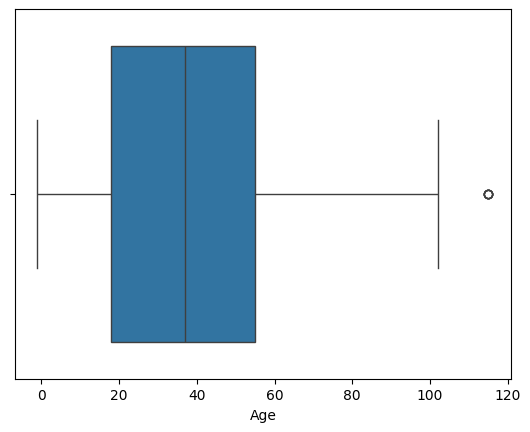

In [12]:
#Outlier Detection & Handling (Age)
sns.boxplot(x=df["Age"])
plt.show()

# Remove invalid age
df = df[df["Age"] >= 0]

## SKEW CHECK

In [13]:
df.skew(numeric_only=True)

PatientId        1.967778
AppointmentID   -1.235602
Age              0.121658
Scholarship      2.699182
Hypertension     1.521691
Diabetes         3.315512
Alcoholism       5.470540
Handicap         8.274360
SMS_received     0.766694
dtype: float64

In [14]:
df["WaitingDays"].skew()

KeyError: 'WaitingDays'

In [ ]:
import numpy as np
df["Age"] = np.log1p(df["Age"])

In [ ]:
# df['WaitingDays'] = np.log1p(df['WaitingDays'])
# df.skew()

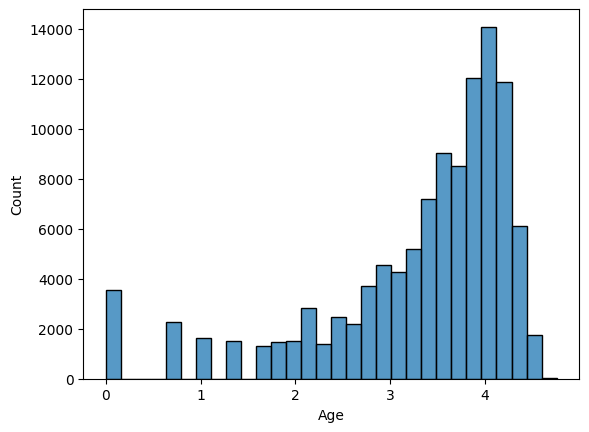

In [ ]:
df["Age"].skew()
sns.histplot(df["Age"], bins=30)
plt.show()

## EDA – EXPLORATORY DATA ANALYSIS

Target Distribution Plot

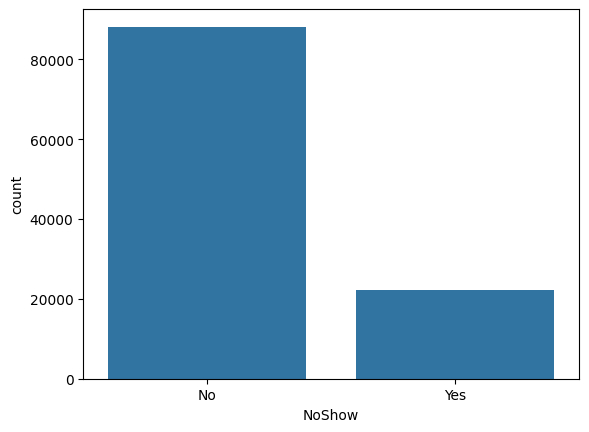

In [ ]:
sns.countplot(x="NoShow", data=df)
plt.show()
#SHOWN YES VS NO


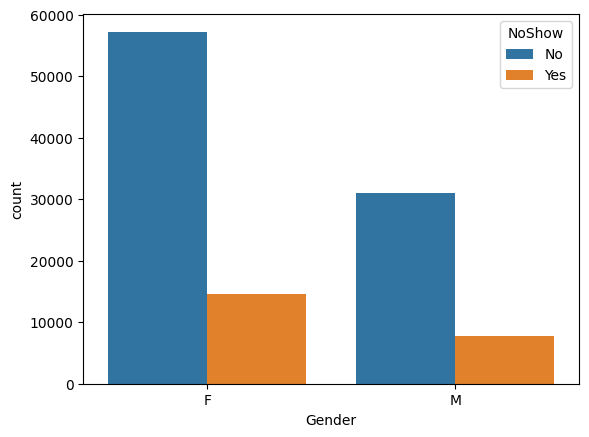

In [ ]:
#Gender vs No-Show
sns.countplot(x="Gender", hue="NoShow", data=df)
plt.show()
#gender impact on no-show

Age Distribution Histogram

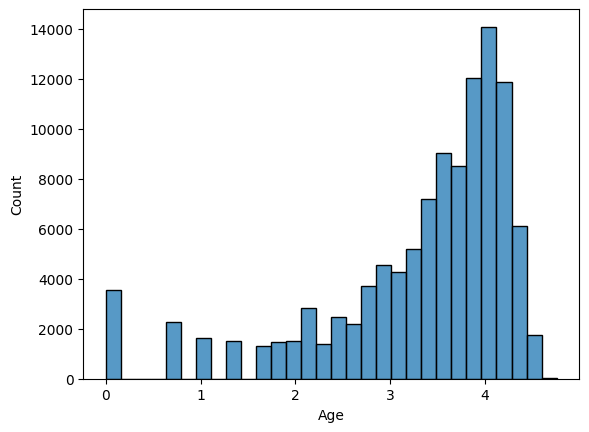

In [ ]:
sns.histplot(df["Age"], bins=30)
plt.show()

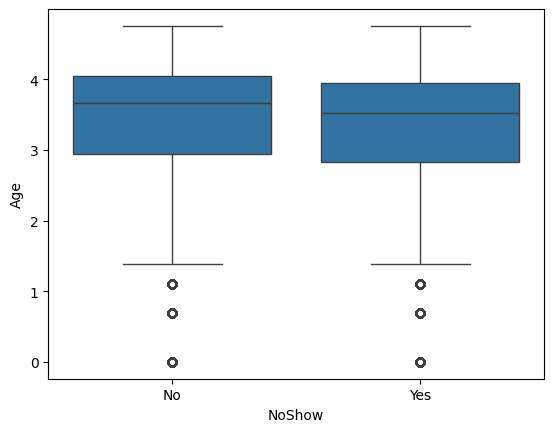

In [ ]:
#Age vs No-Show (Box Plot)
sns.boxplot(x="NoShow", y="Age", data=df)
plt.show()


SMS Received vs No-Show

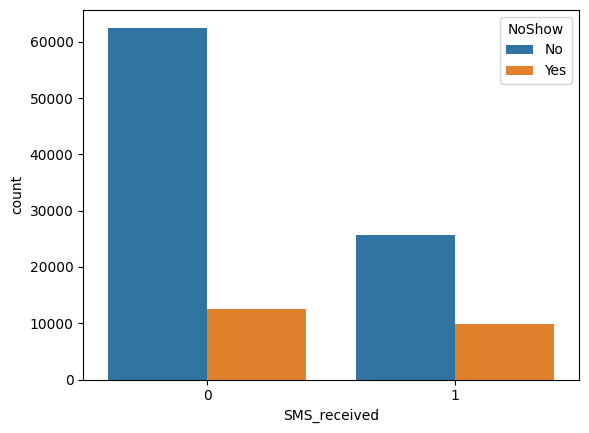

In [ ]:
#SMS reminders reduce no-shows
sns.countplot(x="SMS_received", hue="NoShow", data=df)
plt.show()


In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='rainbow')
plt.show()

ValueError: could not convert string to float: 'F'

<Figure size 1000x600 with 0 Axes>

PAIR PLOT

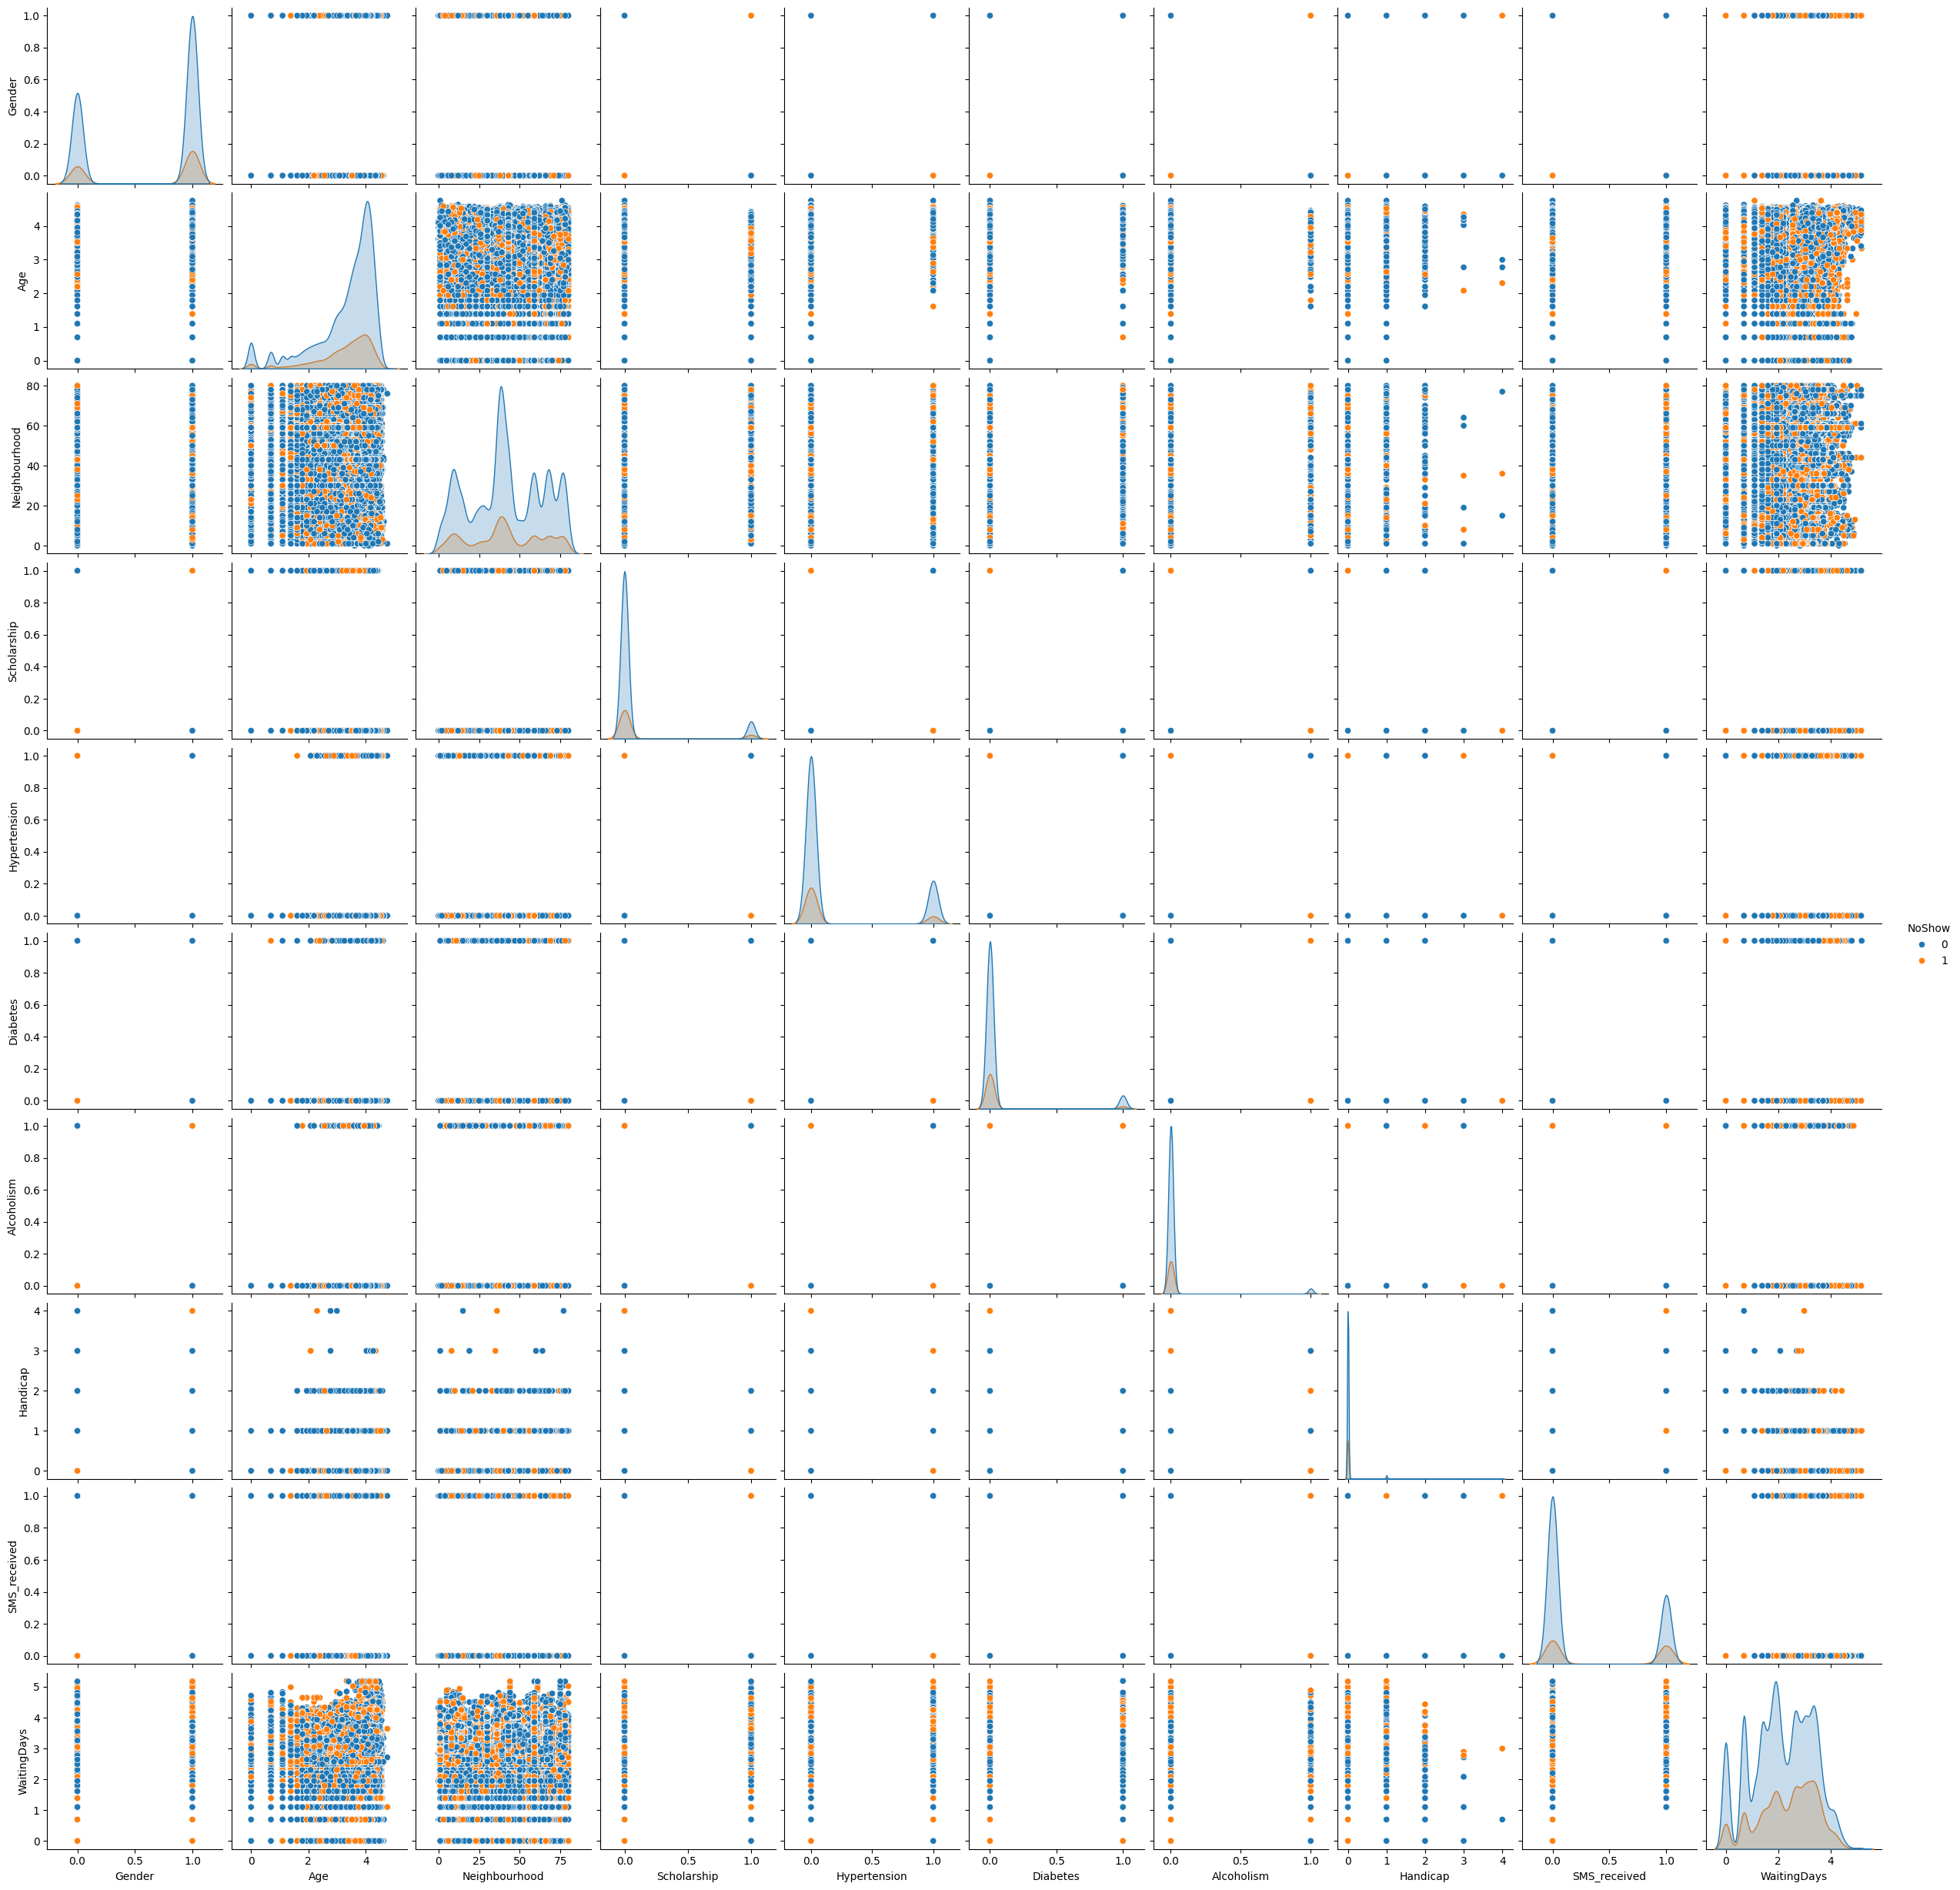

In [ ]:
sns.pairplot(df, hue="NoShow")
plt.show()

# Drop Unnecessary Columns

In [ ]:

#Columns like ID do not help prediction.
df.drop(['PatientId', 'AppointmentID'], axis=1, inplace=True)

## ENCODING

In [ ]:
df

,PatientId,AppointmentID,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays
0,2.987250e+13,5642903,F,4.143135,JARDIM DA PENHA,0,1,0,0,0,0,No,-1
1,5.589978e+14,5642503,M,4.043051,JARDIM DA PENHA,0,0,0,0,0,0,No,-1
2,4.262962e+12,5642549,F,4.143135,MATA DA PRAIA,0,0,0,0,0,0,No,-1
3,8.679512e+11,5642828,F,2.197225,PONTAL DE CAMBURI,0,0,0,0,0,0,No,-1
4,8.841186e+12,5642494,F,4.043051,JARDIM DA PENHA,0,1,1,0,0,0,No,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,4.043051,MARIA ORTIZ,0,0,0,0,0,1,No,34
110523,3.596266e+12,5650093,F,3.951244,MARIA ORTIZ,0,0,0,0,0,1,No,34
110524,1.557663e+13,5630692,F,3.091042,MARIA ORTIZ,0,0,0,0,0,1,No,40
110525,9.213493e+13,5630323,F,3.663562,MARIA ORTIZ,0,0,0,0,0,1,No,40


In [ ]:
df["Gender"] = df["Gender"].map({"M": 0, "F": 1})

In [ ]:
df['NoShow'] = df['NoShow'].map({'Yes': 1, 'No': 0})

# FEATURE ENGINEERING

In [ ]:
#fix the Date
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Create new feature: waiting days
#  How many days have passed since booking the appointment?
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df.drop(['ScheduledDay', 'AppointmentDay'], axis=1, inplace=True)
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'Age', 'Neighbourhood',
       'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap',
       'SMS_received', 'NoShow', 'WaitingDays'],
      dtype='object')

In [ ]:
df = pd.get_dummies(df, drop_first=True)
df

,PatientId,AppointmentID,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,WaitingDays,...,Neighbourhood_SEGURANÇA DO LAR,Neighbourhood_SOLON BORGES,Neighbourhood_SÃO BENEDITO,Neighbourhood_SÃO CRISTÓVÃO,Neighbourhood_SÃO JOSÉ,Neighbourhood_SÃO PEDRO,Neighbourhood_TABUAZEIRO,Neighbourhood_UNIVERSITÁRIO,Neighbourhood_VILA RUBIM,NoShow_Yes
0,2.987250e+13,5642903,62,0,1,0,0,0,0,-1,...,False,False,False,False,False,False,False,False,False,False
1,5.589978e+14,5642503,56,0,0,0,0,0,0,-1,...,False,False,False,False,False,False,False,False,False,False
2,4.262962e+12,5642549,62,0,0,0,0,0,0,-1,...,False,False,False,False,False,False,False,False,False,False
3,8.679512e+11,5642828,8,0,0,0,0,0,0,-1,...,False,False,False,False,False,False,False,False,False,False
4,8.841186e+12,5642494,56,0,1,1,0,0,0,-1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,56,0,0,0,0,0,1,34,...,False,False,False,False,False,False,False,False,False,False
110523,3.596266e+12,5650093,51,0,0,0,0,0,1,34,...,False,False,False,False,False,False,False,False,False,False
110524,1.557663e+13,5630692,21,0,0,0,0,0,1,40,...,False,False,False,False,False,False,False,False,False,False
110525,9.213493e+13,5630323,38,0,0,0,0,0,1,40,...,False,False,False,False,False,False,False,False,False,False


x|y separte

In [ ]:
X = df.drop('NoShow',axis=1)
y = df['NoShow']

KeyError: "['NoShow'] not found in axis"

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## SCALING

In [ ]:
df.sample()

,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,NoShow,WaitingDays
64867,1,4.158883,38,0,0,0,0,0,1,0,3.912023


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ValueError: Input X contains infinity or a value too large for dtype('float64').

## APPLY ALL MODELS

In [ ]:
models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "SVM": SVC(probability=True)
}


In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1_Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1_Score", ascending=False)


NameError: name 'models' is not defined

## BEST MODEL SELECT

In [ ]:
best_model_name = results_df.sort_values(
    by="F1_Score", ascending=False
).iloc[0]["Model"]

final_model = models[best_model_name]
best_model_name


NameError: name 'results_df' is not defined

In [ ]:
with open("final_model.pkl", "wb") as f:
    pickle.dump(final_model, f)


NameError: name 'final_model' is not defined

In [ ]:
#Handle Outliers (Age)
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]
df


,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,NoShow,WaitingDays
0,1,62,39,0,1,0,0,0,0,0,NaN
1,0,56,39,0,0,0,0,0,0,0,NaN
2,1,62,45,0,0,0,0,0,0,0,NaN
3,1,8,54,0,0,0,0,0,0,0,NaN
4,1,56,39,0,1,1,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
110522,1,56,43,0,0,0,0,0,1,0,1.516302
110523,1,51,43,0,0,0,0,0,1,0,1.516302
110524,1,21,43,0,0,0,0,0,1,0,1.550446
110525,1,38,43,0,0,0,0,0,1,0,1.550446


In [ ]:
df

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,NoShow,WaitingDays
0,1,62,39,0,1,0,0,0,0,0,-1
1,0,56,39,0,0,0,0,0,0,0,-1
2,1,62,45,0,0,0,0,0,0,0,-1
3,1,8,54,0,0,0,0,0,0,0,-1
4,1,56,39,0,1,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
110522,1,56,43,0,0,0,0,0,1,0,34
110523,1,51,43,0,0,0,0,0,1,0,34
110524,1,21,43,0,0,0,0,0,1,0,40
110525,1,38,43,0,0,0,0,0,1,0,40


In [ ]:
#Age < 0 removed
#WaitingDays negative values can be removed
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

## Encoding & Scaling

In [ ]:
df['Noshow'] = df['Noshow'].map({'Yes': 1, 'No': 0})
df.head()

KeyError: 'Noshow'

In [ ]:
df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})
df.head()

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Noshow,WaitingDays
0,1,62,JARDIM DA PENHA,0,1,0,0,0,0,0,-1
1,0,56,JARDIM DA PENHA,0,0,0,0,0,0,0,-1
2,1,62,MATA DA PRAIA,0,0,0,0,0,0,0,-1
3,1,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,-1
4,1,56,JARDIM DA PENHA,0,1,1,0,0,0,0,-1


In [ ]:
df.drop(columns=["PatientId","AppointmentID","Neighbourhood"],axis=1,inplace=True)

df

KeyError: "['PatientId', 'AppointmentID'] not found in axis"

### Exploratory Data Analysis (EDA)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


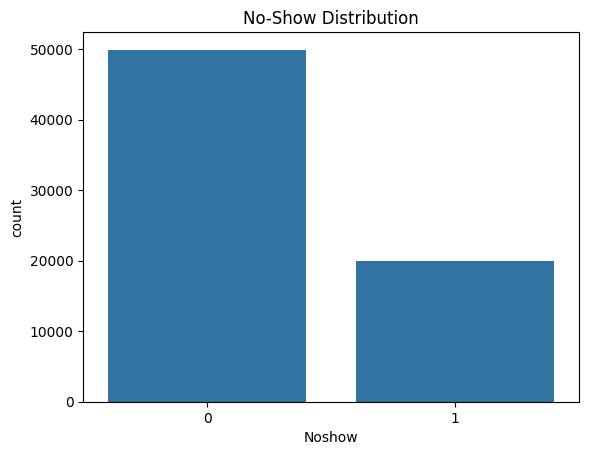

In [ ]:
sns.countplot(x='Noshow', data=df)
plt.title("No-Show Distribution")
plt.show()

## Feature Selection


#### Target

In [ ]:
x=df.drop(columns="Noshow")
y=df["Noshow"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
x_scaler=scaler.fit_transform(x_train)

## TO BULID MULTIPLE MODELS

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


LOGISTICS REGRESSION

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)


DecisionTreeClassifier()

In [ ]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)


RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report


## Model Evaluvation

In [ ]:
models = {'Logistic': lr, 'Decision Tree': dt, 'Random Forest': rf}

for name, model in models.items():
    preds = model.predict(x_test)
    print(name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


Logistic
Accuracy: 0.714664184447945
              precision    recall  f1-score   support

           0       0.72      1.00      0.83      9988
           1       0.39      0.00      0.01      3978

    accuracy                           0.71     13966
   macro avg       0.55      0.50      0.42     13966
weighted avg       0.62      0.71      0.60     13966

Decision Tree
Accuracy: 0.6621079765143921
              precision    recall  f1-score   support

           0       0.73      0.85      0.78      9988
           1       0.34      0.20      0.25      3978

    accuracy                           0.66     13966
   macro avg       0.53      0.52      0.52     13966
weighted avg       0.62      0.66      0.63     13966

Random Forest
Accuracy: 0.6637548331662609
              precision    recall  f1-score   support

           0       0.73      0.84      0.78      9988
           1       0.35      0.21      0.26      3978

    accuracy                           0.66     13966
   ma

## Hyperparameter Tuning (Random Forest)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(x_train, y_train)

best_model = grid.best_estimator_
